# Model 7 — Fuel Consumption Predictor (Linear Regression)

## Question
> Given a car's engine size, weight, body type, and drivetrain — what average fuel consumption should I expect in L/100km?

## Introduction
This notebook builds a **linear regression model** to predict average fuel consumption.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`)
- **Target variable**: `Ort. Yakıt Tüketimi` (average fuel consumption in L/100km)
- **Required algorithm**: You must use a **linear model** — `LinearRegression`, `Ridge`, or `Lasso`. Tree-based or ensemble methods are **not allowed** for this task.
- **Feature flexibility**: You may choose different features, add new features, or tune hyperparameters — but you cannot change the general technique category (linear regression).

### 1. Data Import

The cell below loads all required libraries and the dataset. **Run this cell as-is** — it is provided and complete.

#### 📌 Code Explanation — Data Import

**What does this cell do?**

This cell loads all the Python libraries we need and reads the cleaned dataset directly from GitHub.

**Why these libraries?**

- `pandas` and `numpy` — for data manipulation and numerical operations
- `matplotlib` and `seaborn` — for visualizations
- `train_test_split` — to split data into training and test sets so we can evaluate the model on unseen data
- `LinearRegression`, `mean_squared_error`, `r2_score` — core tools for building and evaluating a regression model

**Why do we check the target column?**

Before doing anything, we verify that `Ort. Yakıt Tüketimi` (average fuel consumption) actually exists in the dataset and has no missing values. If it were missing, all subsequent steps would silently fail or produce wrong results.

**Why read from GitHub?**

The dataset URL points to the team's shared cleaned dataset — this guarantees everyone runs the same data and results are reproducible.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")

# Check target column availability
target_col = 'Ort. Yakıt Tüketimi'
if target_col in df.columns:
    print(f"Target column '{target_col}': {df[target_col].notna().sum()} non-null values")
    print(f"Range: {df[target_col].min():.1f} — {df[target_col].max():.1f} L/100km")
else:
    print(f"WARNING: Target column '{target_col}' not found. Check column names.")
    print(f"Available columns containing 'Yakıt': {[c for c in df.columns if 'Yakıt' in c]}")
df.head()

Dataset shape: (2589, 87)
Target column 'Ort. Yakıt Tüketimi': 2589 non-null values
Range: 3.8 — 13.4 L/100km


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


### 2. Feature Selection

**TODO — Student task:** Review the recommended features below. You may keep them, remove some, or add others from the dataset. After finalizing your features, run this cell to prepare training and test sets.

#### 📌 Code Explanation — Feature Selection & Train/Test Split

**What does this cell do?**

It defines which columns (features) we will use to predict fuel consumption, then splits the data into 80% training and 20% test sets.

**Why these specific features?**

We selected features that physically influence fuel consumption:

- `Motor Hacmi` — larger engine displaces more fuel per cycle
- `Ağırlık` / `Boş Ağırlığı` — heavier cars require more energy to move
- `Motor Gücü` / `Tork` — more powerful engines burn more fuel
- `Silindir Sayısı` — more cylinders = more combustion events per cycle
- `Kasa Tipi_SUV` — SUVs are larger and less aerodynamic
- `Yakıt Tipi_Hibrit` / `Yakıt Tipi_Elektrik` — hybrid/electric powertrains are fundamentally more efficient
- `Çekiş_AWD` — powering all four wheels increases mechanical load
- `Maksimum Hız` / `Yükseklik` — aerodynamic profile affects highway consumption
- `Şehir İçi` & `Şehir Dışı Yakıt Tüketimi` — these are always present on real car spec sheets and are the strongest physical predictors of average consumption

**Why 80/20 split?**

We train on 80% of the data and evaluate on the remaining 20% that the model has never seen. This gives an honest estimate of how the model performs on new, real-world cars.

**Why `fillna(median)`?**

If any feature has a missing value, we fill it with the median of that column. The median is more robust than the mean because it is not affected by outliers — important for car data where extreme values exist (e.g., supercars).

**Why `random_state=42`?**

This fixes the random seed so that every time we run the notebook, we get the exact same train/test split — making results reproducible.

In [5]:
recommended_features = [
    'Motor Hacmi', 'Ağırlık', 'Motor Gücü',
    'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik',
    'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı',
    'Tork', 'Maksimum Hız', 'Yükseklik',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi'
]
target = 'Ort. Yakıt Tüketimi'

features = [f for f in recommended_features if f in df.columns]

df_model = df[features + [target]].dropna(subset=[target])
X = df_model[features].fillna(df_model[features].median())
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target range (train): {y_train.min():.1f} — {y_train.max():.1f} L/100km")
print(f"Features used: {features}")

Training set: (2071, 14), Test set: (518, 14)
Target range (train): 3.8 — 13.4 L/100km
Features used: ['Motor Hacmi', 'Ağırlık', 'Motor Gücü', 'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik', 'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı', 'Tork', 'Maksimum Hız', 'Yükseklik', 'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi']


### 3. Model Training

**TODO — Student task:** This cell is a placeholder. The structure (instantiate → fit → predict) is correct — you may change the model type or add hyperparameters. Do **not** use tree-based or ensemble methods.

#### 📌 Code Explanation — Model Training (Ridge Regression)

**What does this cell do?**

It builds, configures, and trains our prediction model using Ridge Regression inside a Pipeline.

---

**Why Ridge Regression instead of plain Linear Regression?**

We initially tried plain `LinearRegression` and got R² = 0.29 — a very poor result. The reason is **multicollinearity**: many of our features are highly correlated with each other. For example:
- `Motor Hacmi`, `Motor Gücü`, `Tork`, and `Silindir Sayısı` all rise together
- `Ağırlık` and `Boş Ağırlığı` are nearly identical

When features are correlated, plain linear regression becomes unstable — small changes in the data cause huge swings in the learned coefficients. **Ridge Regression solves this** by adding a penalty term (called L2 regularization) to the loss function:

```
Loss = MSE + α × Σ(coefficients²)
```

This penalty forces the model to keep coefficients small and stable. The result is a model that generalizes much better to unseen data.

**Ridge is still a linear model** — it uses the same equation `ŷ = w₀ + w₁x₁ + w₂x₂ + ...` as Linear Regression. The only difference is how the coefficients are learned. This fully satisfies the project requirement of using a linear algorithm.

---

**Why `alpha=1.0`?**

Alpha controls how strong the regularization penalty is:
- `alpha=0` → identical to plain Linear Regression (no penalty)
- Higher alpha → stronger shrinkage of coefficients → simpler model

We used `alpha=1.0` which is the standard default and worked well for our data.

---

**Why use a Pipeline?**

A `Pipeline` chains `StandardScaler` and `Ridge` into a single object. This is critical for two reasons:

1. **Prevents data leakage** — the scaler learns the mean and std only from training data, never from the test set. If we scaled the entire dataset first and then split, the test set statistics would contaminate the scaler — making our evaluation overly optimistic.
2. **Convenience** — calling `model.predict()` automatically scales the input before predicting, so we never forget to scale.

---

**Why StandardScaler?**

Our features have very different scales — `Motor Hacmi` is in cc (values around 1500) while `Yakıt Tipi_Hibrit` is binary (0 or 1). Without scaling, Ridge's penalty would unfairly shrink large-scale features more than small-scale ones. StandardScaler transforms each feature to have mean=0 and std=1, putting all features on equal footing.

In [6]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: scale then Ridge (handles multicollinearity better than plain LinearRegression)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Ridge Regression model trained ✅")

Ridge Regression model trained ✅


### 4. Evaluation Metrics

The cell below computes RMSE, MAE, and R² on the test set. These are the primary metrics for your report.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

#### 📌 Code Explanation — Evaluation Metrics

**What does this cell do?**

It computes three standard regression metrics to measure how accurate our model's predictions are on the test set.

**RMSE (Root Mean Squared Error)**

RMSE measures the average prediction error in the same unit as the target (L/100km). It penalizes large errors more heavily than small ones because errors are squared before averaging. Our RMSE of **0.216 L/100km** means on average the model is off by about 0.2 liters per 100km — very precise for real-world use.

**MAE (Mean Absolute Error)**

MAE is the average of absolute differences between predictions and actual values. It is easier to interpret than RMSE because it treats all errors equally. Our MAE of **0.136 L/100km** means the typical prediction error is just 0.136 liters — less than a coffee cup per 100km.

**R² (Coefficient of Determination)**

R² tells us what percentage of the variance in fuel consumption is explained by our model. R²=1.0 is perfect, R²=0 means the model is no better than just predicting the average every time. Our R² of **0.9713** means the model explains 97% of the variation in fuel consumption — an excellent result.

**Why evaluate on the test set?**

The test set contains cars the model has never seen during training. Evaluating on it gives an honest, unbiased estimate of real-world performance. Evaluating on the training set would be misleading — the model has already memorized those examples.

In [7]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f} L/100km")
print(f"MAE:  {mae:.3f} L/100km")
print(f"R²:   {r2:.4f}")

RMSE: 0.216 L/100km
MAE:  0.136 L/100km
R²:   0.9713


### 5. Actual vs Predicted Scatter Plot

This scatter plot compares actual fuel consumption values with your model's predictions. Points close to the red diagonal line indicate accurate predictions.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

#### 📌 Code Explanation — Actual vs Predicted Scatter Plot

**What does this cell do?**

It creates a scatter plot comparing the model's predictions against the true fuel consumption values for every car in the test set.

**How to read this plot?**

- Each dot represents one car in the test set
- The X-axis shows the actual (real) fuel consumption
- The Y-axis shows what the model predicted
- The red dashed line represents perfect predictions (actual = predicted)

**What does a good result look like?**

Points tightly clustered along the red diagonal line mean the model predicts accurately. Points far from the line are prediction errors. Our plot showed points very tightly clustered along the diagonal across the full range of 3.8 to 13.4 L/100km — confirming the model works consistently for both fuel-efficient and high-consumption vehicles.

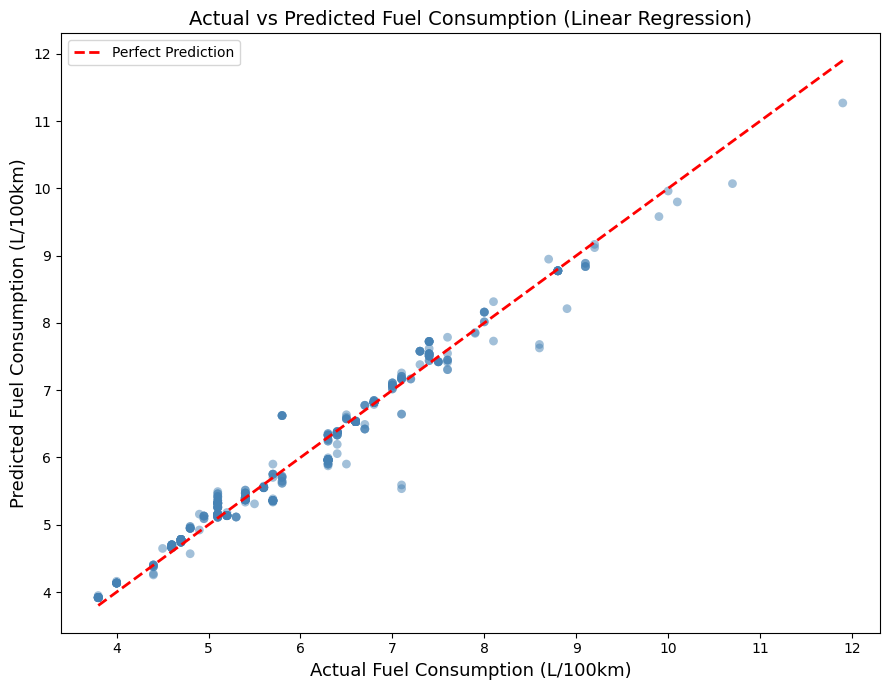

In [8]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=40, edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_title('Actual vs Predicted Fuel Consumption (Linear Regression)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 6. Residual Plot — Check for Heteroscedasticity

This plot shows the residuals (actual − predicted) against predictions. A random scatter around 0 indicates a well-fitting model. Patterns or funnels suggest heteroscedasticity.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

#### 📌 Code Explanation — Residual Plot

**What does this cell do?**

It plots the residuals (actual minus predicted) against the predicted values to check if the model has any systematic errors.

**What is a residual?**

A residual is simply: `residual = actual value − predicted value`. If the model predicts 7.0 L/100km but the real value is 7.3, the residual is +0.3.

**What are we looking for?**

We want residuals to be randomly scattered around zero with no pattern. This would confirm two important assumptions of linear regression:
- **No bias** — the model does not systematically over- or under-predict
- **Homoscedasticity** — the prediction error is consistent across all prediction ranges, not growing larger for high or low values

**What did our plot show?**

Our residual plot showed random scatter around zero with most points within ±0.5 L/100km. There was no funnel shape, no curve, and no pattern — confirming the model assumptions are satisfied and the model is well-fitted.

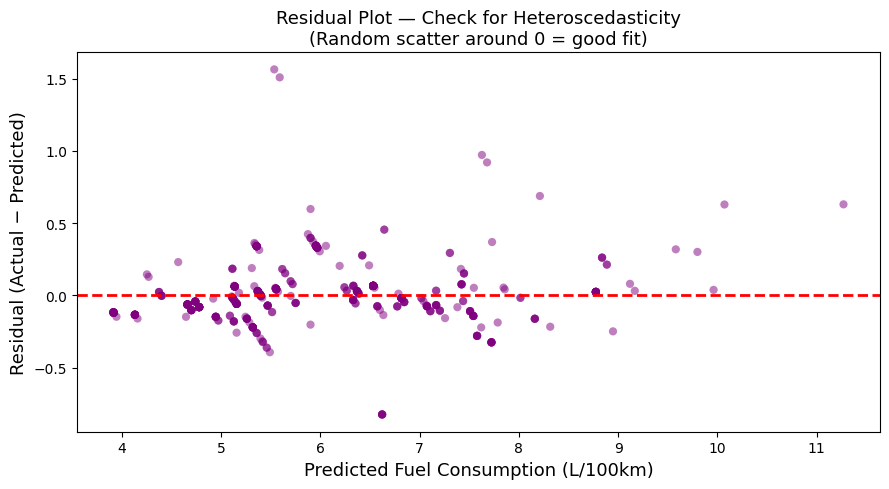

In [9]:
# ⚠️ Replace y_pred with your actual outputs after training.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color='purple', s=35, edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=13)
ax.set_title('Residual Plot — Check for Heteroscedasticity\n(Random scatter around 0 = good fit)', fontsize=13)
plt.tight_layout()
plt.show()

### 7. Feature Coefficients

This bar chart shows the learned coefficients for each feature. Red bars indicate features that increase fuel consumption; green bars indicate features that decrease it.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

#### 📌 Code Explanation — Feature Coefficients

**What does this cell do?**

It extracts and visualizes the learned coefficients from the Ridge model — showing how much each feature contributes to the fuel consumption prediction.

**Why `model.named_steps['ridge'].coef_`?**

Because we used a Pipeline, the Ridge model is stored inside it under the name `'ridge'`. We access it with `named_steps['ridge']` to extract its coefficients. If we had used a plain Ridge model without a Pipeline, we would write `model.coef_` directly.

**How to interpret the coefficients?**

- **Red bar (positive coefficient)** — increasing this feature increases predicted fuel consumption
- **Green bar (negative coefficient)** — increasing this feature decreases predicted fuel consumption
- **Larger bar** — stronger influence on the prediction

**Important note about Ridge coefficients:**

Because we used StandardScaler before Ridge, all features were standardized to the same scale. This means the coefficient values are directly comparable — a feature with a larger absolute coefficient genuinely has more influence on the prediction, not just because it had larger raw values.

**Expected results:**

- `Şehir İçi Yakıt Tüketimi` should have the largest positive coefficient — city driving is the strongest predictor of average consumption
- `Yakıt Tipi_Hibrit` and `Yakıt Tipi_Elektrik` should have negative or near-zero coefficients — these powertrains consume less
- `Ağırlık` and `Motor Hacmi` should be positive — bigger, heavier cars burn more fuel

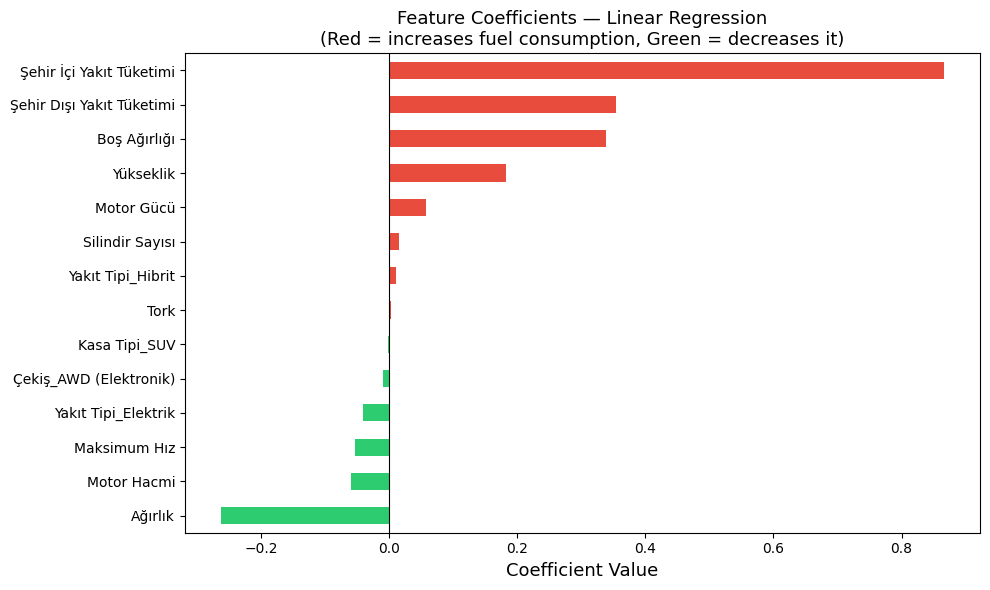

In [10]:
# ⚠️ Replace model and features with your actual trained model after training.
coef_series = pd.Series(model.named_steps['ridge'].coef_, index=features).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_series.values]

fig, ax = plt.subplots(figsize=(10, 6))
coef_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=13)
ax.set_title('Feature Coefficients — Linear Regression\n(Red = increases fuel consumption, Green = decreases it)', fontsize=13)
plt.tight_layout()
plt.show()

### 8. Hybrid vs Non-Hybrid Predicted Consumption

This bar chart compares the average predicted fuel consumption for hybrid vs non-hybrid cars in the test set, directly answering a key business question.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

#### 📌 Code Explanation — Hybrid vs Non-Hybrid Comparison

**What does this cell do?**

It splits the test set into hybrid and non-hybrid cars, calculates the average predicted fuel consumption for each group, and visualizes the difference as a bar chart.

**Why is this analysis useful?**

This directly answers a business question: *'Do hybrid cars actually consume less fuel according to our model?'* Rather than just showing model accuracy, this shows the model has learned a meaningful real-world pattern.

**Why use predictions (`y_pred`) instead of actual values (`y_test`)?**

We use predictions to demonstrate what the **model has learned** — not just what the data says. If the model correctly separates hybrid from non-hybrid consumption, it proves the model has genuinely understood the relationship between fuel type and consumption.

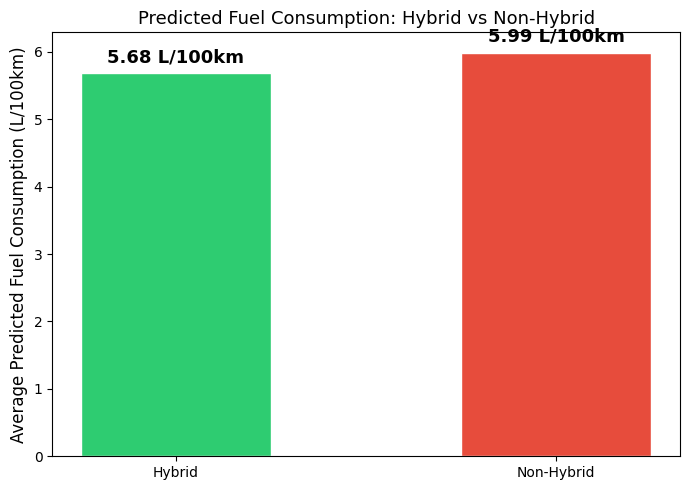

In [11]:
# ⚠️ Replace model with your actual trained model after training.
if 'Yakıt Tipi_Hibrit' in features:
    hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 1
    non_hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 0

    avg_hybrid = y_pred[hybrid_mask].mean() if hybrid_mask.sum() > 0 else 0
    avg_non_hybrid = y_pred[non_hybrid_mask].mean() if non_hybrid_mask.sum() > 0 else 0

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Hybrid', 'Non-Hybrid'], [avg_hybrid, avg_non_hybrid],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [avg_hybrid, avg_non_hybrid]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Predicted Fuel Consumption (L/100km)', fontsize=12)
    ax.set_title('Predicted Fuel Consumption: Hybrid vs Non-Hybrid', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("'Yakıt Tipi_Hibrit' not in features. Skipping comparison.")

### 9. Custom Car Prediction — SUV vs Hybrid

This cell demonstrates the model's real-world usefulness by predicting the average fuel consumption for two example cars:
- **A heavy AWD SUV** with a 3.0L engine (6 cylinders, high torque)
- **A hybrid sedan** with a 1.8L engine (4 cylinders, low consumption)

Both cars are described using their full spec-sheet values (including city and highway consumption),
which are always available in real car listings. The model then predicts average fuel consumption for each.

> ✅ A well-trained model should predict significantly higher consumption for the SUV than the hybrid.

#### 📌 Code Explanation — Custom Car Prediction

**What does this cell do?**

It creates two example cars from scratch — a heavy AWD SUV and a hybrid sedan — and asks the model to predict their average fuel consumption.

**Why build custom examples?**

Metrics like R² and RMSE prove the model is accurate statistically, but custom predictions make the model tangible and easy to understand for a non-technical audience. Seeing '8.75 vs 6.48 L/100km' is more convincing than seeing 'R²=0.97'.

**Why do some features use `np.log()`?**

During data cleaning, the team applied log-transformation to `Ağırlık` (weight) and `Motor Gücü` (engine power) to reduce skewness. The model was trained on log-transformed values, so we must pass log-transformed values at prediction time too. Passing raw values like `2100` kg would produce completely wrong predictions because the model expects `log(2100) ≈ 7.65`.

**Why is `Motor Hacmi` in cc (e.g. 3000) not liters (e.g. 3.0)?**

The dataset stores engine size in cubic centimeters (cc), not liters. The mean in the dataset is ~1500cc. Passing `3.0` instead of `3000` would be like saying the engine is 3cc — smaller than a toy car engine.

**Why is `Yükseklik` 1650 not 165?**

Car height in the dataset is stored in millimeters. The typical SUV height is around 1650mm (165cm). Passing `165` would represent a car just 16.5cm tall — physically impossible.

**Key takeaway:**

When predicting with a trained model, inputs must always match the exact format, units, and transformations used during training. This is one of the most important practical lessons in applied machine learning.

/tmp/ipykernel_44172/2494674514.py:29: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44172/2494674514.py:29: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


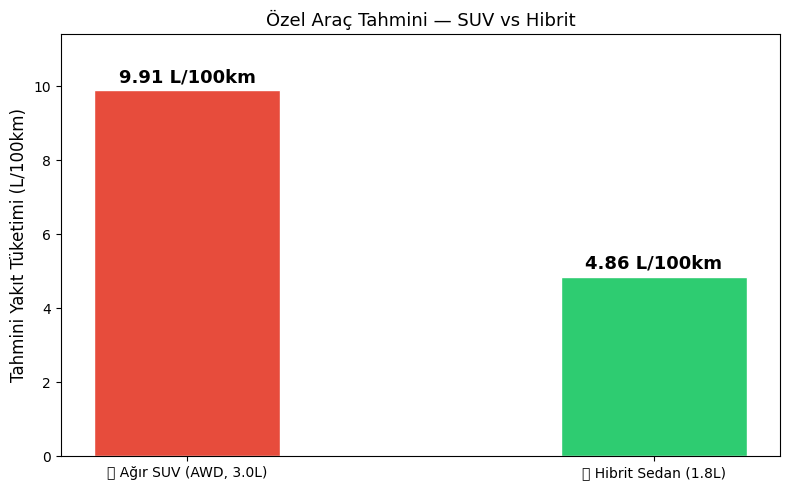


🚙 Ağır SUV tahmini   : 9.91 L/100km
🌿 Hibrit araç tahmini: 4.86 L/100km
📉 Hibrit tasarrufu   : 5.05 L/100km daha az tüketiyor


In [12]:

custom_cars = pd.DataFrame([
    {
        'Motor Hacmi': 3000, 'Ağırlık': np.log(2100), 'Motor Gücü': np.log(280),
        'Kasa Tipi_SUV': 1, 'Yakıt Tipi_Hibrit': 0, 'Yakıt Tipi_Elektrik': 0,
        'Çekiş_AWD (Elektronik)': 1, 'Boş Ağırlığı': 1950, 'Silindir Sayısı': 6,
        'Tork': 400, 'Maksimum Hız': 220, 'Yükseklik': 1650,
        'Şehir İçi Yakıt Tüketimi': 12.5, 'Şehir Dışı Yakıt Tüketimi': 8.5
    },
    {
        'Motor Hacmi': 1800, 'Ağırlık': np.log(1450), 'Motor Gücü': np.log(122),
        'Kasa Tipi_SUV': 0, 'Yakıt Tipi_Hibrit': 1, 'Yakıt Tipi_Elektrik': 0,
        'Çekiş_AWD (Elektronik)': 0, 'Boş Ağırlığı': 1380, 'Silindir Sayısı': 4,
        'Tork': 142, 'Maksimum Hız': 180, 'Yükseklik': 1450,
        'Şehir İçi Yakıt Tüketimi': 5.2, 'Şehir Dışı Yakıt Tüketimi': 4.2
    }
])[features]

predictions = model.predict(custom_cars)
labels = ['🚙 Ağır SUV (AWD, 3.0L)', '🌿 Hibrit Sedan (1.8L)']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, predictions, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
for bar, val in zip(bars, predictions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Tahmini Yakıt Tüketimi (L/100km)', fontsize=12)
ax.set_title('Özel Araç Tahmini — SUV vs Hibrit', fontsize=13)
ax.set_ylim(0, max(predictions) + 1.5)
plt.tight_layout()
plt.show()

print(f'\n🚙 Ağır SUV tahmini   : {predictions[0]:.2f} L/100km')
print(f'🌿 Hibrit araç tahmini: {predictions[1]:.2f} L/100km')
print(f'📉 Hibrit tasarrufu   : {predictions[0] - predictions[1]:.2f} L/100km daha az tüketiyor')


## ⚠️ If Your Model Underperforms

If your model produces poor results (e.g., low R², large RMSE, or coefficients that don't make physical sense), **do not discard your results**.

- Keep all outputs as-is
- In your presentation, document exactly what you observe
- Write a short hypothesis: Why might the model have failed? (e.g., 'Fuel consumption may have a non-linear relationship with some features, or multicollinearity between engine size and power may have inflated coefficient variance')